<a href="https://colab.research.google.com/github/mariakorotnian/E-commerce-Sales-Behavioral-Analytics-Portfolio-Project/blob/main/Portfolio_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Підключення до бази даних в BigQuery:


In [ ]:
!pip install --upgrade google-cloud-bigquery

from google.colab import auth
from google.cloud import bigquery
auth.authenticate_user()
client = bigquery.Client(project="data-analytics-mate")

##Написання SQL запиту:

In [ ]:
query = """
SELECT
  s.date,
  s.ga_session_id as session_id,
  acs.account_id,
  ac.is_verified,
  ac.is_unsubscribed,
  sp.browser,
  sp.device,
  sp.channel,
  sp.country,
  sp.continent,
  sp.mobile_model_name,
  sp.operating_system,
  sp.language as browser_language,
  sp.name as traffic_source,
  p.category,
  p.price,
  p.name as product_name,
  p.short_description
FROM `data-analytics-mate.DA.session` AS s
LEFT JOIN `data-analytics-mate.DA.account_session` AS acs
  ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` AS ac
  ON acs.account_id = ac.id
LEFT JOIN `data-analytics-mate.DA.session_params` AS sp
  ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.order` AS o
  ON o.ga_session_id = s.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` AS p
  ON o.item_id = p.item_id
  ORDER BY s.date
  """

##Створення датафрейму та перевірка даних:

In [ ]:
df = client.query(query).to_dataframe()
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   session_id         349545 non-null  Int64  
 2   account_id         27945 non-null   Int64  
 3   is_verified        27945 non-null   Int64  
 4   is_unsubscribed    27945 non-null   Int64  
 5   browser            349545 non-null  object 
 6   device             349545 non-null  object 
 7   channel            349545 non-null  object 
 8   country            349545 non-null  object 
 9   continent          349545 non-null  object 
 10  mobile_model_name  349545 non-null  object 
 11  operating_system   349545 non-null  object 
 12  browser_language   235279 non-null  object 
 13  traffic_source     349545 non-null  object 
 14  category           33538 non-null   object 
 15  price              33538 non-null   float64
 16  pr

,date,session_id,account_id,is_verified,is_unsubscribed,browser,device,channel,country,continent,mobile_model_name,operating_system,browser_language,traffic_source,category,price,product_name,short_description
0,2020-11-01,65223751,<NA>,<NA>,<NA>,Chrome,mobile,Organic Search,United States,Americas,<Other>,Web,en-us,(organic),None,NaN,None,None
1,2020-11-01,7115337200,<NA>,<NA>,<NA>,Chrome,desktop,Organic Search,United Kingdom,Europe,Chrome,Web,en-us,(organic),Bookcases & shelving units,609.0,VITTSJÖ,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,<NA>,<NA>,<NA>,Chrome,mobile,Direct,Norway,Europe,<Other>,Web,zh,(direct),Tables & desks,189.0,RÅSKOG,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,<NA>,<NA>,<NA>,Chrome,mobile,Direct,Nigeria,Africa,<Other>,Android,es-es,(direct),Bookcases & shelving units,609.0,VITTSJÖ,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,<NA>,<NA>,<NA>,Chrome,desktop,Direct,China,Asia,Chrome,Windows,en-us,(direct),Bookcases & shelving units,609.0,VITTSJÖ,"Shelving unit with laptop table, 202x36x175 cm"


In [ ]:

print("Унікальні сесії:", df["session_id"].nunique())

print("Розглядається період з", df["date"].min(), "по", df["date"].max())

count_number_columns = df.select_dtypes(include="number").shape[1]
count_number_columns = df.select_dtypes(include="number").columns.tolist()

count_category_columns = df.select_dtypes(include="object").shape[1]
count_category_columns = df.select_dtypes(include="object").columns.tolist()

print("Кількість числових колонок:", count_number_columns)
print("Назви числових колонок:", count_number_columns)

print("Кількість категоріальних колонок:", count_category_columns)
print("Назви категоріальних колонок:", count_category_columns)

df.isna().sum()



Унікальні сесії: 349545
Розглядається період з 2020-11-01 по 2021-01-31
Кількість числових колонок: ['session_id', 'account_id', 'is_verified', 'is_unsubscribed', 'price']
Назви числових колонок: ['session_id', 'account_id', 'is_verified', 'is_unsubscribed', 'price']
Кількість категоріальних колонок: ['browser', 'device', 'channel', 'country', 'continent', 'mobile_model_name', 'operating_system', 'browser_language', 'traffic_source', 'category', 'product_name', 'short_description']
Назви категоріальних колонок: ['browser', 'device', 'channel', 'country', 'continent', 'mobile_model_name', 'operating_system', 'browser_language', 'traffic_source', 'category', 'product_name', 'short_description']


,0
date,0
session_id,0
account_id,321600
is_verified,321600
is_unsubscribed,321600
browser,0
device,0
channel,0
country,0
continent,0


###**Опис датафрейму:**

*date* — дата;

*session_id* — унікальний ідентифікатор для кожної сесії;

*continent* — континент, з якого було розміщено замовлення;

*country*— країна, з якої було розміщено замовлення;

*device* — пристрій, з якого було розміщено замовлення;

*browser* — браузер, з якого було розміщено замовлення;

*mobile_model_name* — назва моделі пристрою, з якого було - розміщено замовлення;

*operating_system* — операційна система пристрою, з якого було розміщено замовлення;

*browser_language* — мова браузера;

*traffic_source* — загальний маркетинговий канал або тип реферера (наприклад, органічний, реферальний);

*channel* — конкретна назва маркетингового каналу;

*account_id* — унікальний ідентифікатор облікового запису клієнта;

*is_verified* — вказує, чи підтверджено обліковий запис клієнта (наприклад, 1 — так, 0 — ні);

*is_unsubscribed* — вказує, чи відмовився клієнт від маркетингових повідомлень (наприклад, 1 — так, 0 — ні);

*category* — категорія товару (наприклад, електроніка, стільці, книги);

*product_name* — повна назва товару;

*price* — ціна продажу товару;

*short_description* — короткий опис товару.

**Загальна кількість колонок**: 18.

**Кількість колонок числового типу (5)**:

в датасеті є числові типу int64, а саме:



session_id (349545), account_id (27945), is_verified (27945), is_unsubscribed (27945)

та типу float64: price (33538).

**Кількість колонок категоріального типу object (12)**:
device (349545), channel (349545), country (349545), continent (349545), mobile_model_name (349545), operating_system (349545), browser_language (235279), traffic_source (349545), category (33538).

Але 2 колонки is_verified та is_unsubscribed, які потрібно перевести в булевий тип.

**Кількість колонок типу dbdate (1):** date.

**Кількість унікальних сесій:** 349545.

**Який період часу розглядається:** 01.11.2020 - 31.01.2021

**Пропущені значення:**

browser_language - 114266

account_id - 321600

is_veryfied - 321600

is_unsubscribed - 321600

category - 316007

product_name - 316007

price - 316007

short_description - 316007

**В яких колонках більше пропущених значень, яка причина?**
Найбільше всього пропусків в колонках account_id, is_verified, is_unsubscribed -  по 321600. Це означає, що деяка кількість користувачів не створила акаунтів та/або не увійшла у систему, тому немає account_id та незаповнені поля is_verified та відповідно is_unsubscribed.
Відсутність даних в колонках category, price, product_name, short_description, означає, що не у всі сесії користувачі робили замовлення.
Відсутність даних у колонці browser_language  означає, що браузер не завжди передає мову.

##Перетворення типів даних:

In [ ]:
import pandas as pd
df["date"] = pd.to_datetime(df["date"], format="%m/%d/%y %H:%M")
df["is_verified"] = df["is_verified"].astype("boolean")
df["is_unsubscribed"] = df["is_unsubscribed"].astype("boolean")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   date               349545 non-null  datetime64[ns]
 1   session_id         349545 non-null  Int64         
 2   account_id         27945 non-null   Int64         
 3   is_verified        27945 non-null   boolean       
 4   is_unsubscribed    27945 non-null   boolean       
 5   browser            349545 non-null  object        
 6   device             349545 non-null  object        
 7   channel            349545 non-null  object        
 8   country            349545 non-null  object        
 9   continent          349545 non-null  object        
 10  mobile_model_name  349545 non-null  object        
 11  operating_system   349545 non-null  object        
 12  browser_language   235279 non-null  object        
 13  traffic_source     349545 non-null  object  

##Найбільші продажі та найбільша кількість замовлень на ТОП-3 континентах:

In [ ]:
#визначення ТОП-3 континентів по продажам
top_3_continents_sales = df.groupby("continent")["price"].sum().sort_values(ascending=False).head(3)
print("Топ-3 континенти по продажам, $:\n",top_3_continents_sales, "\n")

#по кількості замовлень
top_3_continents_orders = df.groupby("continent")["session_id"].nunique().sort_values(ascending=False).head(3)
print("Топ-3 континенти по кількості замовлень:\n", top_3_continents_orders)



Топ-3 континенти по продажам, $:
 continent
Americas    17665280.0
Asia         7601298.3
Europe       5934624.2
Name: price, dtype: float64 

Топ-3 континенти по кількості замовлень:
 continent
Americas    193179
Asia         83113
Europe       65135
Name: session_id, dtype: int64


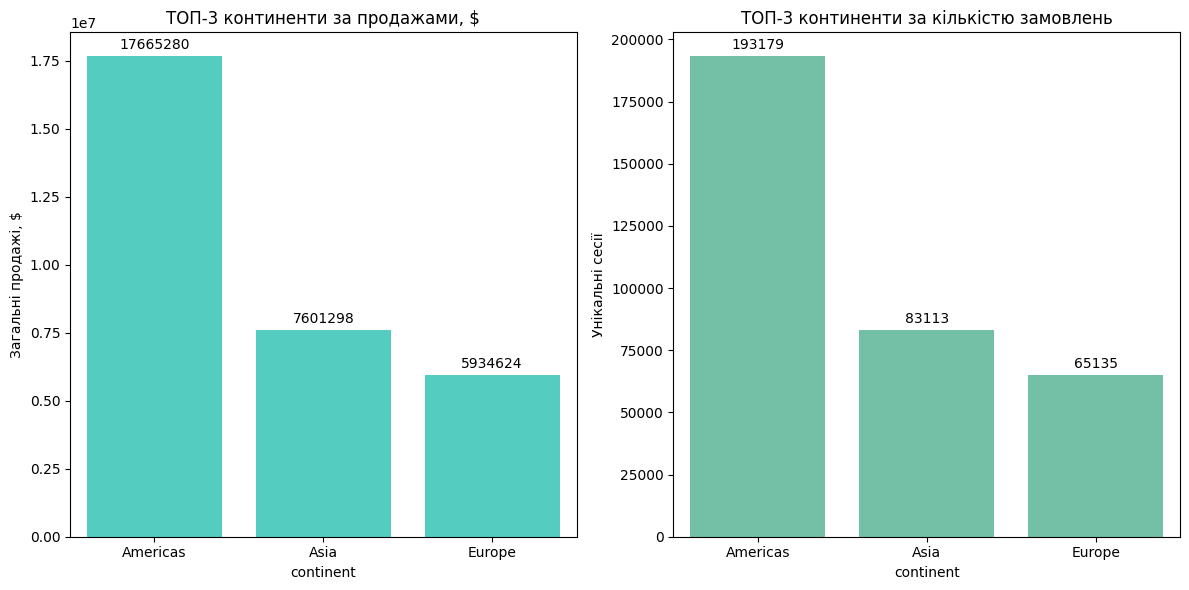

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

ax0 = sns.barplot(x=top_3_continents_sales.index, y=top_3_continents_sales.values, color="turquoise", ax=axes[0])
axes[0].set_title("ТОП-3 континенти за продажами, $")
axes[0].set_ylabel("Загальні продажі, $")

axes[0].bar_label(axes[0].containers[0], padding=3, fmt="%.0f")


ax1 = sns.barplot(x=top_3_continents_orders.index, y=top_3_continents_orders.values, color="mediumaquamarine", ax=axes[1])
axes[1].set_title("ТОП-3 континенти за кількістю замовлень")
axes[1].set_ylabel("Унікальні сесії")

axes[1].bar_label(axes[1].containers[0], padding=3, fmt="%.0f")

plt.tight_layout()
plt.show()

##Найбільші продажі та найбільша кількість замовлень в ТОП-5 країнах:

In [ ]:
top_5_countries_sales = df.groupby("country")["price"].sum().sort_values(ascending=False).head(5)
print("Топ-5 країн за продажами, $:\n",top_5_countries_sales, "\n")

top_5_countries_orders = df.groupby("country")["session_id"].nunique().sort_values(ascending=False).head(5)
print("Топ-5 країн за кількістю замовлень:\n",top_5_countries_orders)


Топ-5 країн за продажами, $:
 country
United States     13943553.9
India              2809762.0
Canada             2437921.0
United Kingdom      938317.9
France              710692.8
Name: price, dtype: float64 

Топ-5 країн за кількістю замовлень:
 country
United States     153470
India              32763
Canada             25994
United Kingdom     11003
France              6958
Name: session_id, dtype: int64


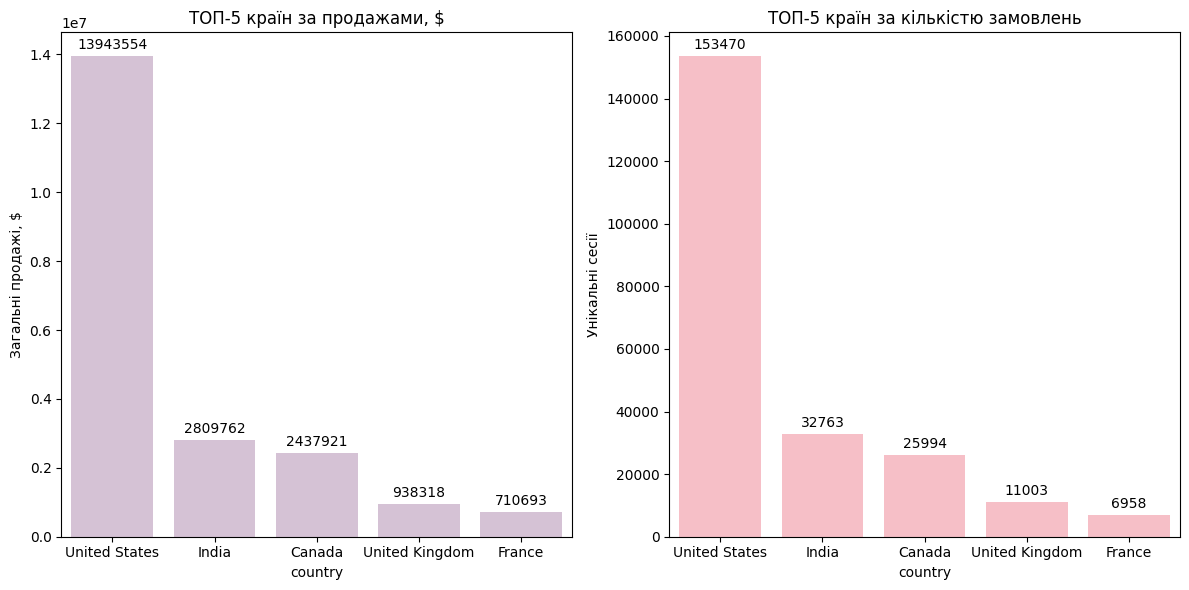

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

ax0 = sns.barplot(x=top_5_countries_sales.index, y=top_5_countries_sales.values, color="thistle", ax=axes[0])
axes[0].set_title("ТОП-5 країн за продажами, $")
axes[0].set_ylabel("Загальні продажі, $")

axes[0].bar_label(axes[0].containers[0], padding=3, fmt="%.0f")


ax1 = sns.barplot(x=top_5_countries_orders.index, y=top_5_countries_orders.values, color="lightpink", ax=axes[1])
axes[1].set_title("ТОП-5 країн за кількістю замовлень")
axes[1].set_ylabel("Унікальні сесії")

axes[1].bar_label(axes[1].containers[0], padding=3, fmt="%.0f")

plt.tight_layout()
plt.show()

In [ ]:

top_country = df.groupby("country")["price"].sum().idxmax()
print(f"Країна з найвищими продажами: {top_country}\n")

#ТОП-10 категорій за продажами
top_10_category = df.groupby("category")["price"].sum().sort_values(ascending=False).head(10)
print("ТОП-10 категорій товарів за продажами:\n", top_10_category, "\n")

#ТОП-10 категорій товарів у країнах ТОП-10 (за продажами)
top_10_category = df[df["country"] == top_country].groupby("category")["price"].sum().sort_values(ascending=False).head(10)
print("ТОП-10 категорій товарів за продажами в країнах ТОП-10:\n", top_10_category, "\n")


Країна з найвищими продажами: United States

ТОП-10 категорій товарів за продажами:
 category
Sofas & armchairs                   8388254.5
Chairs                              6147748.8
Beds                                4919725.0
Bookcases & shelving units          3640818.1
Cabinets & cupboards                2336499.5
Outdoor furniture                   2142222.2
Tables & desks                      1790307.5
Chests of drawers & drawer units     906562.5
Bar furniture                        735503.0
Children's furniture                 467697.0
Name: price, dtype: float64 

ТОП-10 категорій товарів за продажами в країнах ТОП-10:
 category
Sofas & armchairs                   3707144.5
Chairs                              2619773.8
Beds                                2213058.0
Bookcases & shelving units          1567606.9
Cabinets & cupboards                 994545.5
Outdoor furniture                    929245.2
Tables & desks                       777865.0
Chests of drawers & drawer u

Порівняльний аналіз категорій товарів за обсягами продажів на глобальному рівні та в межах ТОП-10 країн не виявив значних розбіжностей у структурі попиту. ТОП-10 країн генерують майже половину загального доходу, при цьому пріоритетність категорій залишається незмінною. Це вказує на високу ефективність глобальної маркетингової стратегії та відсутність потреби в локальній адаптації асортименту для ключових ринків.

In [ ]:
#загальні продажі
total_sales = df["price"].sum()
print ("Загальний дохід: ", total_sales, "\n")

#відсоток від загального доходу по девайсам, %
device_sales_percent = (df.groupby("device")["price"].sum() / total_sales * 100).sort_values(ascending=False)
print("Відсоток від загального доходу по девайсам, %:\n", device_sales_percent, "\n")

#відсоток від загальних продажів в розрізі моделей девайсів
mobile_model_percent = (df.groupby("mobile_model_name")["price"].sum() / total_sales * 100).sort_values(ascending=False)
print("Відсоток від загального доходу в розрізах моделей девайсів, %: \n", mobile_model_percent, "\n")

#відсоток від загальних продажів в розрізі джерел трафіку
traffic_source_percent = (df.groupby("traffic_source")["price"].sum() / total_sales * 100).sort_values(ascending=False)
print("Відсоток від загального доходу в розрізі джерел трафіку, %:\n ", traffic_source_percent)


Загальний дохід:  31971731.1 

Відсоток від загального доходу по девайсам, %:
 device
desktop    59.002245
mobile     38.734924
tablet      2.262831
Name: price, dtype: float64 

Відсоток від загального доходу в розрізах моделей девайсів, %: 
 mobile_model_name
Chrome        27.835602
<Other>       20.440966
Safari        20.302504
iPhone        20.082667
ChromeBook     5.725241
Edge           2.180746
iPad           1.403910
Firefox        1.316998
Pixel 4 XL     0.369976
Pixel 3        0.341390
Name: price, dtype: float64 

Відсоток від загального доходу в розрізі джерел трафіку, %:
  traffic_source
(organic)         34.202840
(direct)          23.442345
<Other>           18.445594
(referral)        17.646386
(data deleted)     6.262836
Name: price, dtype: float64


Користувачі найчастіше приймають рішення про покупку та завершують транзакції з комп"ютерів. Це може бути пов’язано з тим, що, наприклад, меблі - це дорогі покупки, які зручніше розглядати на великому екрані.
Desktop (59%) приносить більше грошей, ніж Mobile (38.7%).

Моделі: Серед мобільних пристроїв домінує iPhone (20.1% від загального доходу). Це вказує на преміальність аудиторії. Chrome лідирує як браузер (27.8%).

---



У розрізі моделей ми бачимо високі частки Chrome (27.8%), Safari (20.3%) та iPhone (20.1%). Це свідчить про те, що значна частина мобільної аудиторії — це користувачі Apple, які традиційно мають вищий середній чек.


---



Органіка та прямі заходи разом генерують майже 58% доходу:

- (organic) — 34.2%: Бренд має гарну видимість у пошукових системах. Це "безкоштовні" гроші, які свідчать про якісну SEO-оптимізацію.

- (direct) — 23.4%: Це ядро лояльної аудиторії. Люди знають адресу сайту або мають його в закладках. Це найстабільніший сегмент доходу.

- Referral (17.6%): Досить високий показник, що вказує на ефективність зовнішніх партнерств або згадок у медіа/блогах.

In [ ]:
#всі користувачі
total_users = df["account_id"].nunique()

#всі зареєстровані користувачі, які підтвердили свою електронну адресу
is_verified_users = df[df["is_verified"]== True]["account_id"].nunique()

#відсоток зареєстрованих користувачів, які підтвердили свою електронну адресу
is_verified_percent = is_verified_users / total_users * 100
print("Відсоток зареєстрованих користувачів, які підтвердили електронну адресу:\n", is_verified_percent, "\n")

#всі зареєстровані користувачі, які відписалися від розсилки
is_unsubscribed_users = df[df["is_unsubscribed"] == True]["account_id"].nunique()

#відсоток зареєстрованих користувачів, які відписалися від розсилки
is_unsubscribed_percent = is_unsubscribed_users / total_users * 100
print("Відсоток зареєстрованих користувачів, які відписалися:\n", is_unsubscribed_percent)

Відсоток зареєстрованих користувачів, які підтвердили електронну адресу:
 71.69797817140812 

Відсоток зареєстрованих користувачів, які відписалися:
 16.94399713723385


In [ ]:
#дохід від всіх акаунтів, які не відписалися
subscribed_revenue = df[df["is_unsubscribed"] != 1]["price"].sum()
print("Загальний дохід від підписаних користувачів:\n", subscribed_revenue, "\n")

#дохід від всіх акаунтів, які  відписалися
unsubscribed_revenue = df[df["is_unsubscribed"] != 0]["price"].sum()
print("Загальний дохід від відписавшихся користувачів:\n", unsubscribed_revenue, "\n")

# відсоток доходу від всіх акаунтів, які  відписалися
unsubscribed_revenue_percent = unsubscribed_revenue / total_sales * 100
print("Відсоток доходів від користувачів, які відписалися від загального доходу:\n", unsubscribed_revenue_percent, "\n")

# відсоток доходу від всіх акаунтів, які не відписалися
subscribed_revenue_percent = subscribed_revenue / total_sales * 100
print("Відсоток доходів від користувачів, які не відписалися від загального доходу:\n", subscribed_revenue_percent, "\n")

#дохід від всіх акаунтів, які  зареєструвалися
is_verified_revenue = df[df["is_verified"] == True]["price"].sum()
print("Загальний дохід від всіх зареєстрованих користувачів:\n", is_verified_revenue, "\n")

#дохід від всіх акаунтів, які  не зареєструвалися
is_not_verified_revenue = df[df["is_verified"] == False]["price"].sum()
print("Загальний дохід від всіх незареєстрованих користувачів:\n", is_not_verified_revenue, "\n")


# відсоток доходу від всіх акаунтів, які зареєструвалися
is_verified_revenue_percent = unsubscribed_revenue / total_sales * 100
print("Відсоток доходів від користувачів, які відписалися від загального доходу:\n", is_verified_revenue_percent, "\n")

# відсоток доходу від всіх акаунтів, які не зареєструвалися
is_not_verified_revenue_percent = subscribed_revenue / total_sales * 100
print("Відсоток доходів від користувачів, які не відписалися від загального доходу:\n", is_not_verified_revenue_percent, "\n")



Загальний дохід від підписаних користувачів:
 2150796.9 

Загальний дохід від відписавшихся користувачів:
 431721.6 

Відсоток доходів від користувачів, які відписалися від загального доходу:
 1.3503228794514663 

Відсоток доходів від користувачів, які не відписалися від загального доходу:
 6.727183127096923 

Загальний дохід від всіх зареєстрованих користувачів:
 1866017.4 

Загальний дохід від всіх незареєстрованих користувачів:
 716501.1000000001 

Відсоток доходів від користувачів, які відписалися від загального доходу:
 1.3503228794514663 

Відсоток доходів від користувачів, які не відписалися від загального доходу:
 6.727183127096923 



Підписані користувачі приносять у 5 разів більше грошей (6.73% проти 1.35%), ніж ті, хто відписався.

Хоча база зареєстрованих клієнтів невелика, вона якісна. Ті, хто залишається в підписці, конвертуються значно краще. Але ми маємо дуже багато пропущених даних у колонці (підписаних на розсилку)  - цілих 92 % всіх доходів від анонімів. Тому варто подумати, як мотивувати "гостей" реєструватися (наприклад, знижка на перше замовлення або розширена гарантія в особистому кабінеті).

In [ ]:
registered_only = df[df["account_id"].notnull()] #всі зареєстровані користувачі

#ТОП-10 країн, в яких найбільше зареєструвалося користувачів
top_10_registered_countries_accounts =registered_only.groupby("country")["account_id"].sum().sort_values(ascending=False).head(10)

print("ТОП_10 країн, в яких найбільше зареєстрованих користувачів:", top_10_registered_countries_accounts)




ТОП_10 країн, в яких найбільше зареєстрованих користувачів: country
United States     8159921923
India             1770486019
Canada            1361815313
United Kingdom     566652762
France             364259497
Spain              353092626
Taiwan             329444605
China              323240440
Germany            322980685
Italy              254698285
Name: account_id, dtype: Int64


Найбільше акаунтів створюють у США, Індії та Канаді.

In [ ]:
#Найпопулярніший день продажів за кількістю замовлень

# Витягуємо назву дня тижня
df["day_of_week"] = df["date"].dt.day_name()

# Рахуємо замовлення по днях
weekday_sales = df[df["price"] > 0].groupby("day_of_week")["session_id"].nunique()

# Сортуємо по порядку днів тижня
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_sales = weekday_sales.reindex(days_order)

print("Продажі по днях тижня:")
print(weekday_sales, "\n")



#Найпопулярніший день продажів за кількістю замовлень

# Рахуємо замовлення по днях
weekday_revenue = df.groupby("day_of_week")["price"].sum()
best_day = weekday_revenue.idxmax()
max_rev = weekday_revenue.max()

print(f"Найприбутковіший день тижня: {best_day}")
print(f"Загальний дохід у цей день: {max_rev:,.2f} $")

Продажі по днях тижня:
day_of_week
Monday       4962
Tuesday      5763
Wednesday    5614
Thursday     5015
Friday       4586
Saturday     3724
Sunday       3874
Name: session_id, dtype: int64 

Найприбутковіший день тижня: Wednesday
Загальний дохід у цей день: 5,466,542.90 $


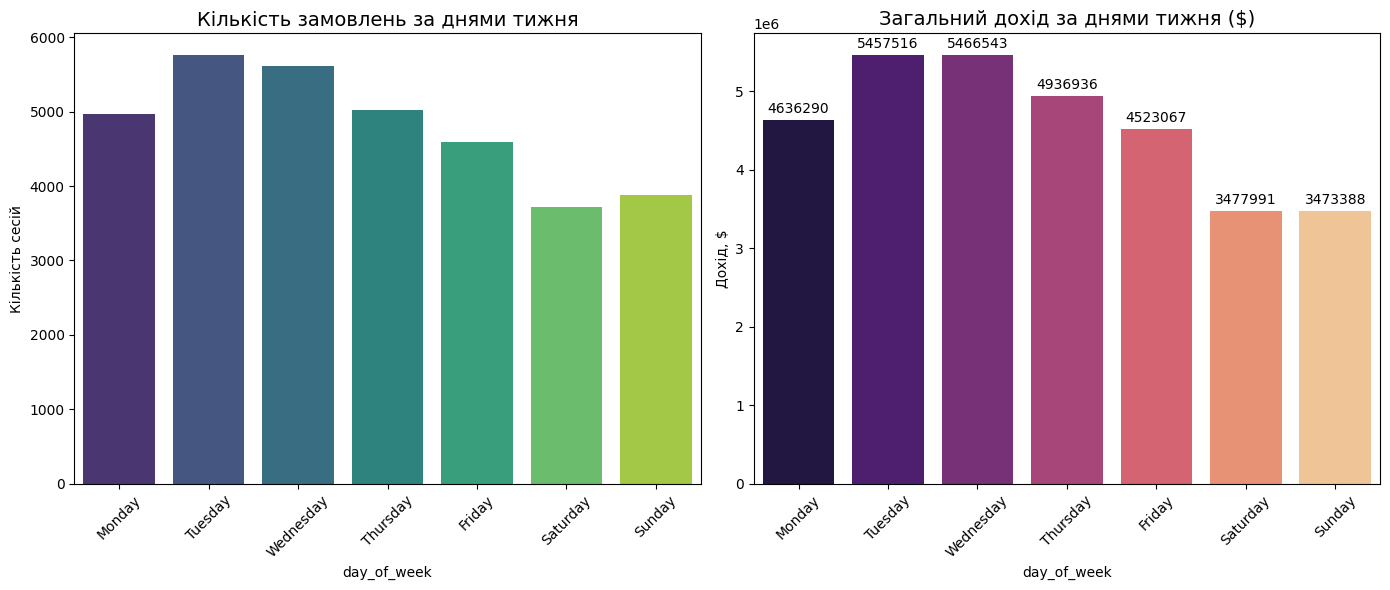

In [ ]:
# Групуємо замовлення (nunique) та дохід (sum)
weekday_data = df[df["price"] > 0].groupby("day_of_week").agg({"session_id": "nunique", "price": "sum"}).reindex(days_order)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
#Графік 1: Кількість замовлень по днях
sns.barplot(
    x=weekday_data.index, y=weekday_data["session_id"], ax=axes[0], hue=weekday_data.index, palette="viridis", legend=False)
axes[0].set_title("Кількість замовлень за днями тижня", fontsize=14)
axes[0].set_ylabel("Кількість сесій")
axes[0].tick_params(axis="x", rotation=45)


# Графік 2: Загальний дохід по днях
sns.barplot(x=weekday_data.index, y=weekday_data["price"], ax=axes[1], hue=weekday_data.index, palette="magma", legend=False)
axes[1].set_title("Загальний дохід за днями тижня ($)", fontsize=14)
axes[1].set_ylabel("Дохід, $")
axes[1].tick_params(axis="x", rotation=45)
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3, fmt="%.0f")

plt.tight_layout()
plt.show()

Найбільше роблять замовлень по вівторках, найбільш прибутковий день тижня - середа. Але спостерігається однакова тенденція і по кількості замовлень, і по продажам у вихідні - в ці дні найменші доходи, і найменша кількість замовлень.

In [ ]:
#Найприбутковіший місяць (сезонність)
# Витягуємо назву дня тижня
df["month"] = df["date"].dt.month_name()

# Рахуємо замовлення по днях
month_orders = df[df["price"] > 0].groupby("month")["session_id"].nunique()

# Сортуємо по порядку місяців
months_orders = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
month_orders = month_orders.reindex(months_orders).fillna(0)

print("Продажі по місяцях:")
print(month_orders, "\n")





Продажі по місяцях:
month
January      10095.0
February         0.0
March            0.0
April            0.0
May              0.0
June             0.0
July             0.0
August           0.0
September        0.0
October          0.0
November     10540.0
December     12903.0
Name: session_id, dtype: float64 



Маємо тільки 3 місяці продажів, тому про сезонність впродовж року не можемо робити висновки.

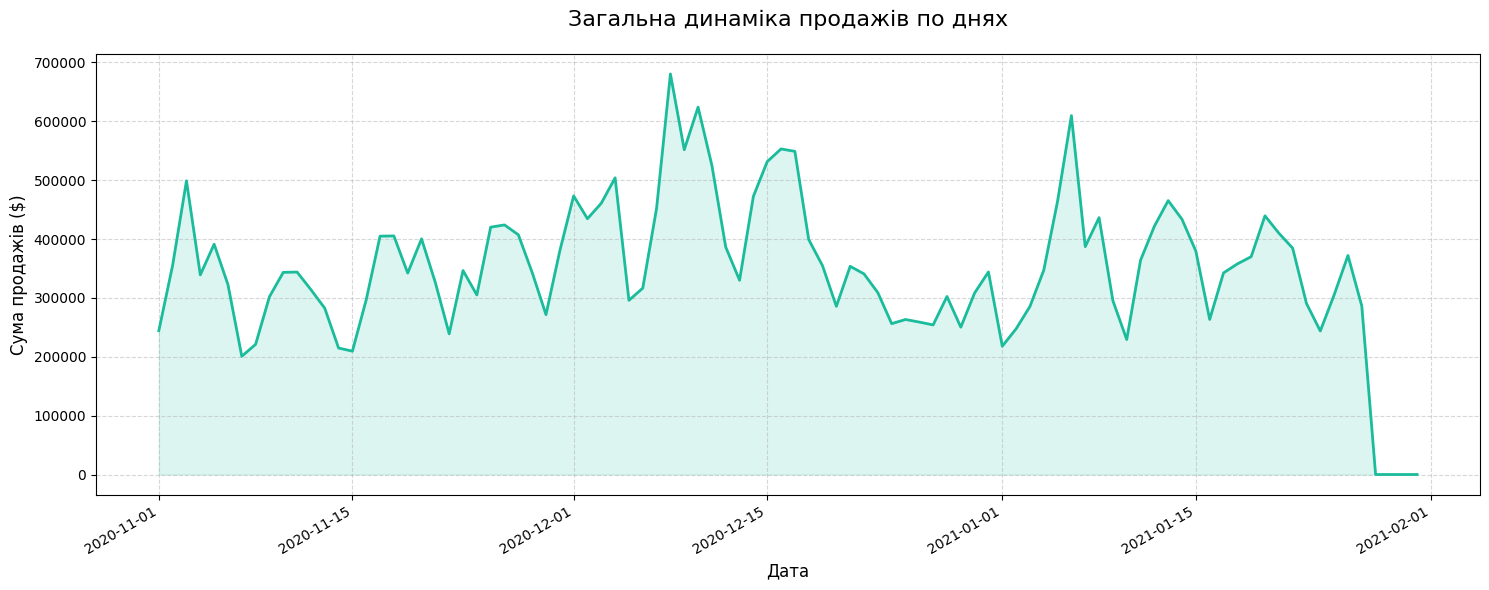

Топ-5 дат за найбільшим доходом:
         date     price
37 2020-12-08  680509.5
39 2020-12-10  624104.6
66 2021-01-06  609763.8
45 2020-12-16  553134.9
38 2020-12-09  551811.6


In [ ]:

# Групуємо дані за кожною датою та сумуємо дохід
daily_sales = df.groupby("date")["price"].sum().reset_index()

# 3. Створюємо візуалізацію динаміки
plt.figure(figsize=(15, 6))

# Побудова лінійного графіка
sns.lineplot(data=daily_sales, x="date", y="price", color="#1ABC9C", linewidth=2)

# Заповнюємо область під графіком для кращого сприйняття об"єму
plt.fill_between(daily_sales["date"], daily_sales["price"], color="#1ABC9C", alpha=0.15)

# Додаємо інтерактивності та візуальних акцентів
plt.title("Загальна динаміка продажів по днях", fontsize=16, pad=20)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Сума продажів ($)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

# Автоматичне форматування дат на осі X, щоб вони не накладалися
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

# топ-5 найуспішніших днів для швидкого аналізу
print("Топ-5 дат за найбільшим доходом:")
print(daily_sales.sort_values(by="price", ascending=False).head(5))

Бачимо декількі піків. Максимальний пік продажів був у середині грудня. Найвищий прибуток було зафіксовано 8 грудня (680,509 $).

Це свідчить про те, що клієнти роблять основні покупки за 2-3 тижні до свят, щоб встигнути отримати замовлення.

Другий потужний сплеск ми бачимо 6 січня ($609,763). Це може бути пов’язано з православним Різдвом (якщо частина клієнтів зі Східної Європи) або з великим післясвятковим розпродажем, який запустили.

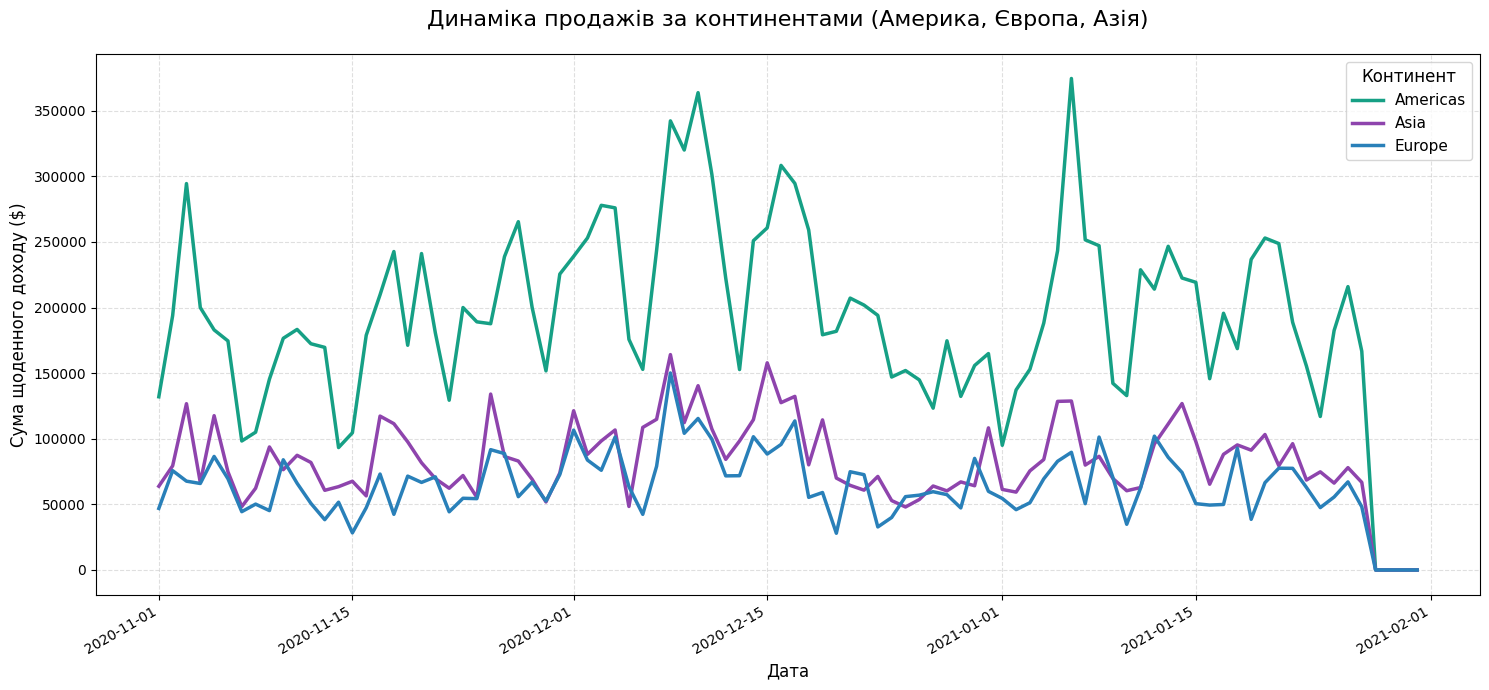

Загальний дохід за вибраними континентами:
continent
Americas    $17,665,280.00
Asia         $7,601,298.30
Europe       $5,934,624.20
Name: price, dtype: object


In [ ]:

# 1.топ-3 континенти
continents_to_plot = ["Americas", "Europe", "Asia"]
df_filtered = df[df["continent"].isin(continents_to_plot)].copy()

# Перетворюємо дату
df_filtered["date"] = pd.to_datetime(df_filtered["date"])

# 2. Групуємо за датою та континентом
daily_continent_sales = df_filtered.groupby(["date", "continent"])["price"].sum().reset_index()


plt.figure(figsize=(15, 7))

sns.lineplot(data=daily_continent_sales, x="date", y="price", hue="continent", palette={"Americas": "#16A085", "Europe": "#2980B9", "Asia": "#8E44AD"},linewidth=2.5)

plt.title("Динаміка продажів за континентами (Америка, Європа, Азія)", fontsize=16, pad=20)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Сума щоденного доходу ($)", fontsize=12)
plt.legend(title="Континент", title_fontsize="12", fontsize="11")
plt.grid(True, linestyle="--", alpha=0.4)

# Автоматичне форматування дат
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

# Додатково: виведемо частку кожного континенту в загальному доході для контексту
total_rev_per_cont = df_filtered.groupby("continent")["price"].sum()
print("Загальний дохід за вибраними континентами:")
print(total_rev_per_cont.apply(lambda x: f"${x:,.2f}"))

Найбільші доходи були в Америці.Будь-які зміни в купівельній спроможності або маркетингу в США матимуть критичний вплив на весь бізнес. Спостерігається тижнева циклічність (люди купують у певні дні) або про те, що продажі дуже сильно стимулюються короткими акціями та розсилками. Попит не є рівномірним.
Азійський ринок зараз є пріоритетнішим і перспективнішим за європейський. Європа виглядає найбільш стабільною, але й найменш прибутковою серед цієї трійки.


In [ ]:
unique_sources = df["traffic_source"].unique()

print("Усі унікальні джерела трафіку:")
print(unique_sources)

Усі унікальні джерела трафіку:
['(organic)' '(direct)' '(data deleted)' '(referral)' '<Other>']


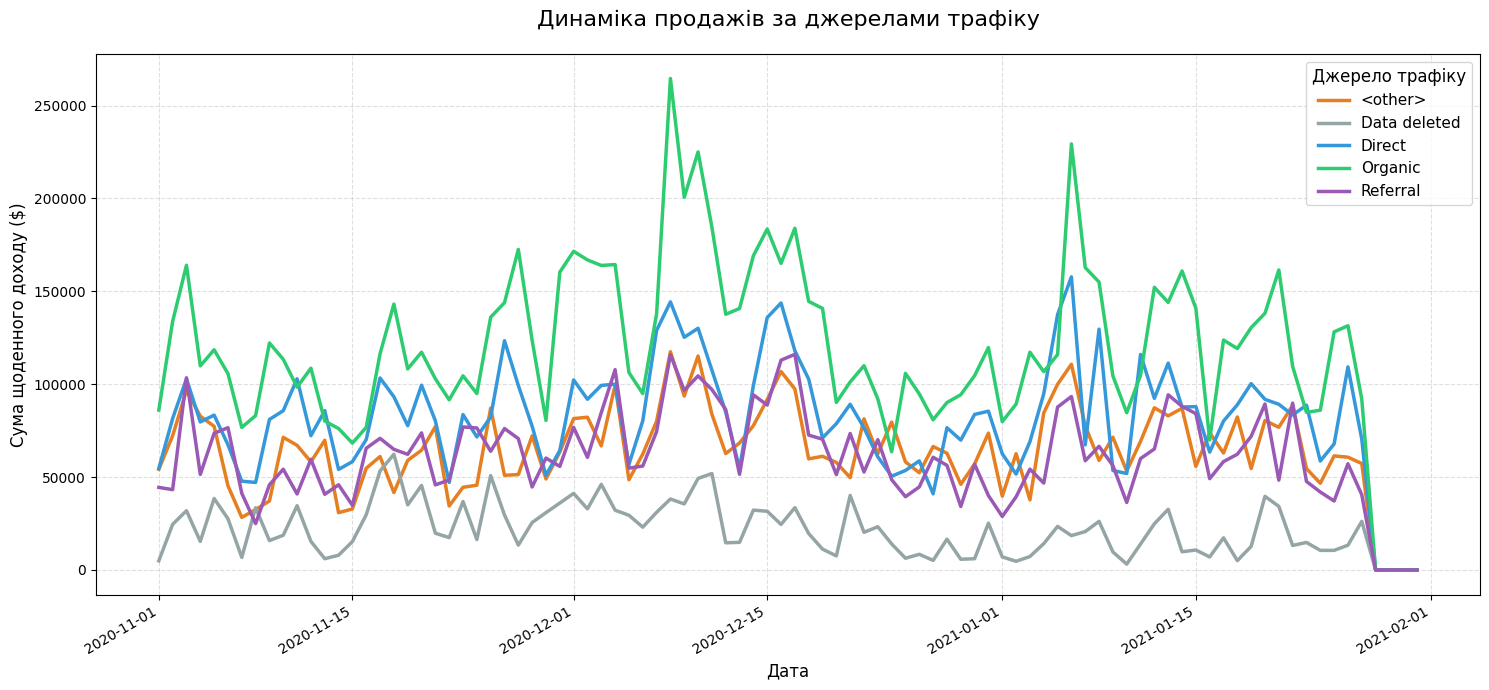

Загальний дохід за вибраними джерелами трафіку:
traffic_source
<other>          $5,897,375.60
Data deleted     $2,002,337.00
Direct           $7,494,923.40
Organic         $10,935,239.90
Referral         $5,641,855.20
Name: price, dtype: object


In [ ]:

# 1. Очищення назв від дужок та зайвих символів
df["traffic_source"] = df["traffic_source"].str.replace(r"[\(\)]", "", regex=True).str.capitalize()

# 2. Групуємо за датою та каналом трафіку
daily_traffic_sales = df.groupby(["date", "traffic_source"])["price"].sum().reset_index()


plt.figure(figsize=(15, 7))

sns.lineplot(data=daily_traffic_sales, x="date", y="price", hue="traffic_source", palette = {"Organic": "#2ECC71", "Direct": "#3498DB", "Referral": "#9B59B6", "Data deleted": "#95A5A6", "<other>": "#E67E22"},linewidth=2.5)

plt.title("Динаміка продажів за джерелами трафіку", fontsize=16, pad=20)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Сума щоденного доходу ($)", fontsize=12)
plt.legend(title="Джерело трафіку", title_fontsize="12", fontsize="11")
plt.grid(True, linestyle="--", alpha=0.4)

# Автоматичне форматування дат
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

# Додатково: виведемо частку кожного континенту в загальному доході для контексту
total_rev_per_cont = df.groupby("traffic_source")["price"].sum()
print("Загальний дохід за вибраними джерелами трафіку:")
print(total_rev_per_cont.apply(lambda x: f"${x:,.2f}"))

Organic - це найбільш стабільне і прибуткове джерело, яке приносить основну масу доходу. На другому місці за доходами - це Direct. Це означає, що велика кількість людей вводить адресу сайту напряму. Це ознака високої лояльності клієнтів, які повертаються знову, не використовуючи пошук або рекламу.

Бачимо, що в середині грудня був пік майже по всім джерелам трафіку (Organic, Direct, Referral, Other) - можливо це повязано з передноворічними знижками.

Варто спробувати сильніше "розкачати" Referral або соціальні мережі (Other), щоб диверсифікувати джерела доходу, тому що доходи від цих джерел - на останніх місцях по прибутковості.

In [ ]:
unique_devices = df["device"].unique()

print("Усі унікальні девайси:")
print(unique_devices)

Усі унікальні девайси:
['mobile' 'desktop' 'tablet']


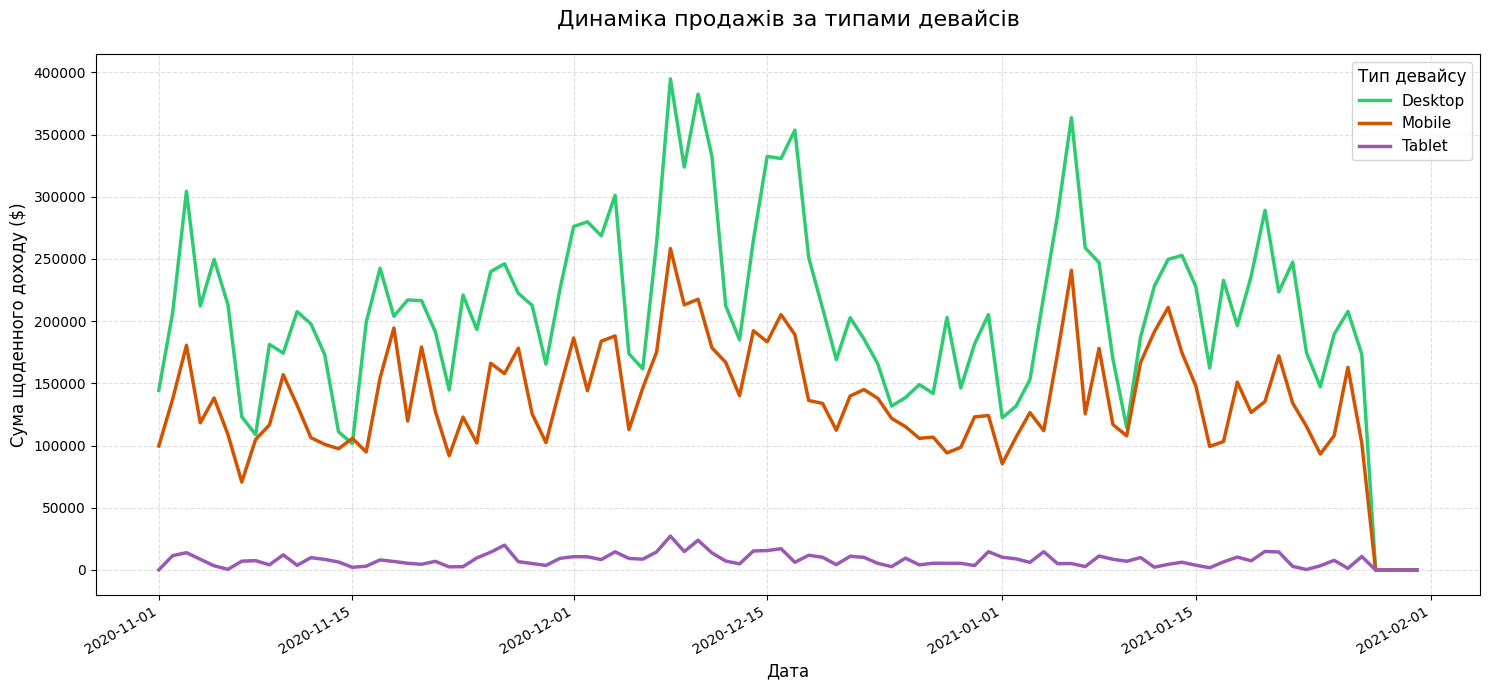

Загальний дохід за вибраними типами девайсів:
device
Desktop    $18,864,039.00
Mobile     $12,384,225.80
Tablet        $723,466.30
Name: price, dtype: object


In [ ]:

df["device"] = df["device"].str.capitalize()

# 2. Групуємо за датою та каналом трафіку
daily_device_sales = df.groupby(["date", "device"])["price"].sum().reset_index()


plt.figure(figsize=(15, 7))

sns.lineplot(data=daily_device_sales, x="date", y="price", hue="device", palette = {"Mobile": "#D35400", "Desktop": "#2ECC71", "Tablet": "#9B59B6"},linewidth=2.5)

plt.title("Динаміка продажів за типами девайсів", fontsize=16, pad=20)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Сума щоденного доходу ($)", fontsize=12)
plt.legend(title="Тип девайсу", title_fontsize="12", fontsize="11")
plt.grid(True, linestyle="--", alpha=0.4)

# Автоматичне форматування дат
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

# Додатково: виведемо частку кожного континенту в загальному доході для контексту
total_rev_per_cont = df.groupby("device")["price"].sum()
print("Загальний дохід за вибраними типами девайсів:")
print(total_rev_per_cont.apply(lambda x: f"${x:,.2f}"))

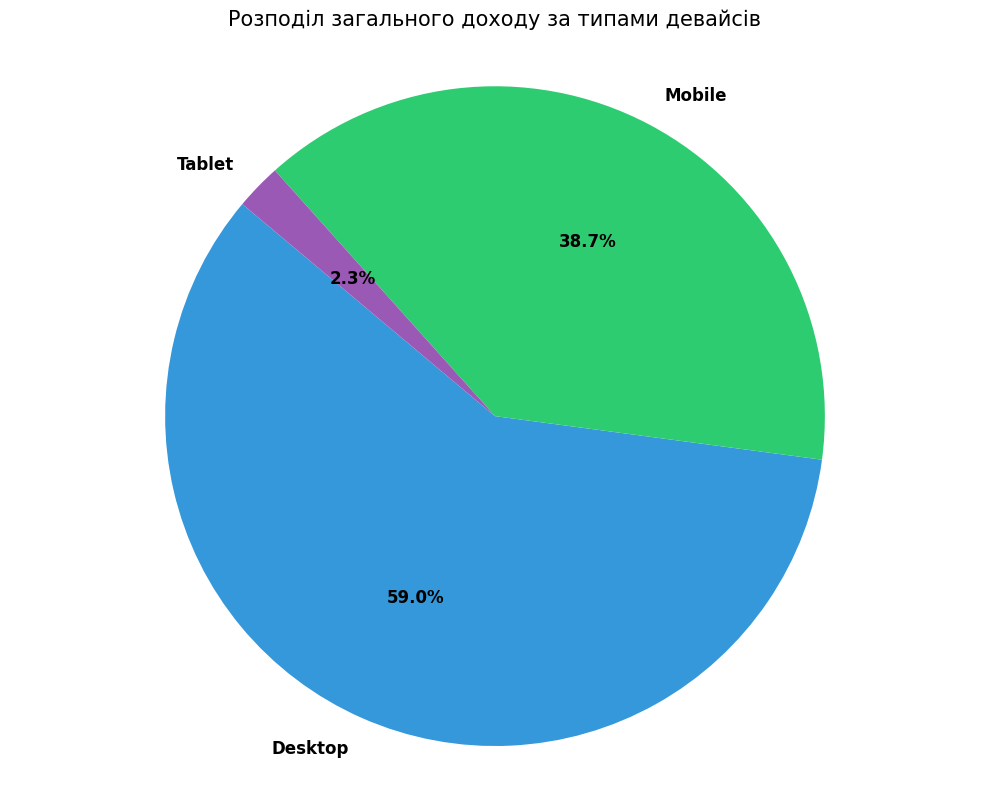

Частка доходу в цифрах:
device
Desktop    $18,864,039.00
Mobile     $12,384,225.80
Tablet        $723,466.30
Name: price, dtype: object


In [ ]:

device_shares = df.groupby("device")["price"].sum()


colors = ["#3498DB", "#2ECC71", "#9B59B6"] # Desktop, Mobile, Tablet
explode=(0.2,0,0)
plt.figure(figsize=(10, 8))


plt.pie(device_shares, labels=device_shares.index, autopct="%1.1f%%", startangle=140, colors=colors, explode=None, textprops={"fontsize": 12, "fontweight": "bold"})

plt.title("Розподіл загального доходу за типами девайсів", fontsize=15, pad=20)
plt.axis("equal")
plt.tight_layout()
plt.show()


print("Частка доходу в цифрах:")
print(device_shares.apply(lambda x: f"${x:,.2f}"))

Desktop — основне джерело доходу. Це характерно для товарів з високим середнім чеком або складним процесом оформлення замовлення, де людям важливо бачити деталі на великому екрані.
Мобільні продажі займають значну частку ринку (приблизно 40% від ТОП-2). Це означає, що мобільна версія сайту працює добре, і значна частина аудиторії купує "на ходу".
Планшети не є пріоритетним пристроєм для аудиторії. На них можна витрачати мінімум ресурсів при тестуванні оновлень.

In [ ]:
# Очищуємо дані від порожніх значень (NaN) у потрібних колонках
df_clean = df.dropna(subset=["traffic_source", "device"])


exclude_values = ["Data deleted", "unknown", "<other>"]
df_clean = df_clean[~df_clean["traffic_source"].isin(exclude_values)]
df_clean = df_clean[~df_clean["device"].isin(exclude_values)]


pivot_sessions = df_clean.pivot_table(index="traffic_source", columns="device", values="session_id",  aggfunc="nunique", observed=True, fill_value=0)


print("Зведена таблиця: Кількість унікальних сесій:\n\n", pivot_sessions)

Зведена таблиця: Кількість унікальних сесій:

 device          Desktop  Mobile  Tablet
traffic_source                         
(data deleted)    12497    8448     469
(direct)          47825   31745    1812
(organic)         69431   46934    2659
(referral)        35890   24183    1363
<Other>           38786   25957    1546


In [ ]:
df_clean = df.dropna(subset=["traffic_source", "device"])


exclude_values = ["Data deleted", "unknown", "<other>"]
df_clean = df_clean[~df_clean["traffic_source"].isin(exclude_values)]
df_clean = df_clean[~df_clean["device"].isin(exclude_values)]


pivot_revenue = df_clean.pivot_table(index="traffic_source", columns="device", values="price",  aggfunc="sum", observed=True, fill_value=0)


print("Зведена таблиця: Загальний дохід ($):")
display(pivot_revenue.style.format("${:,.2f}"))

Зведена таблиця: Загальний дохід ($):


device,Desktop,Mobile,Tablet
traffic_source,,,
(data deleted),"$1,185,492.20","$752,595.90","$64,248.90"
(direct),"$4,472,609.40","$2,875,317.90","$146,996.10"
(organic),"$6,509,258.80","$4,219,962.40","$206,018.70"
(referral),"$3,279,303.60","$2,226,910.00","$135,641.60"
,"$3,417,375.00","$2,309,439.60","$170,561.00"


In [ ]:

top_countries = df.groupby("country")["price"].sum().nlargest(5).index

top_categories = df.groupby("category")["price"].sum().nlargest(10).index

df_top = df[(df["country"].isin(top_countries)) & (df["category"].isin(top_categories))].copy()


pivot_sales = df_top.pivot_table(index="category", columns="country", values="price", aggfunc="sum", fill_value=0)

pivot_sales = pivot_sales.loc[pivot_sales.sum(axis=1).sort_values(ascending=False).index]

print("Зведена таблиця: Топ-10 категорій у Топ-5 країнах (Загальні продажі):")
display(pivot_sales.style.format("${:,.2f}").background_gradient(cmap="YlGn"))

Зведена таблиця: Топ-10 категорій у Топ-5 країнах (Загальні продажі):


country,Canada,France,India,United Kingdom,United States
category,,,,,
Sofas & armchairs,"$692,427.50","$187,735.00","$788,430.00","$234,812.00","$3,707,144.50"
Chairs,"$417,740.80","$134,029.40","$544,309.20","$188,519.40","$2,619,773.80"
Beds,"$354,772.00","$116,414.00","$358,319.50","$133,816.00","$2,213,058.00"
Bookcases & shelving units,"$278,981.90","$73,830.00","$364,507.40","$113,987.60","$1,567,606.90"
Cabinets & cupboards,"$181,802.00","$59,101.50","$191,888.00","$71,684.50","$994,545.50"
Outdoor furniture,"$185,322.80","$40,486.40","$162,289.40","$57,002.40","$929,245.20"
Tables & desks,"$132,678.00","$42,299.00","$186,157.50","$49,374.00","$777,865.00"
Chests of drawers & drawer units,"$71,952.00","$21,544.50","$73,111.00","$36,784.00","$382,388.00"
Bar furniture,"$51,724.00","$11,199.00","$57,657.00","$22,103.00","$330,805.00"


United States — абсолютний лідер: Продажі в США в рази (а інколи й у 10-15 разів) перевищують показники будь-якої іншої країни. Наприклад, категорія Sofas & armchairs у США принесла понад 3.7 млн USD, тоді як у другій за обсягом Індії — лише 788 тис USD.

Sofas & armchairs є найтемнішою коміркою в кожному стовпці. Це товар з найвищим чеком або найбільшим обсягом попиту.

Попри те, що Канада ближча до США географічно, Індія демонструє вищі продажі в категоріях меблів для вітальні (Sofas, Chairs, Bookcases). Це вказує на успішну експансію на азійський ринок.

Категорії на кшталт Bar furniture та Children's furniture приносять найменше грошей. Вони мають світло-жовтий колір по всій горизонталі. Це нормально для вузькоспеціалізованих товарів, але в США навіть ці «слабкі» категорії приносять більше (207–330 тис. USD), ніж топові товари у Франції.

In [ ]:
top_countries = df.groupby("country")["price"].sum().nlargest(5).index

top_categories = df.groupby("category")["price"].sum().nlargest(10).index

df_top = df[(df["country"].isin(top_countries)) & (df["category"].isin(top_categories))].copy()


pivot_sales = df_top.pivot_table(index="category", columns="country", values="price", aggfunc="count", fill_value=0)

pivot_sales = pivot_sales.loc[pivot_sales.sum(axis=1).sort_values(ascending=False).index]

print("Зведена таблиця: Топ-10 категорій у Топ-5 країнах (Кількість замовлень):")
display(pivot_sales.style.format("{:,.2f}").background_gradient(cmap="GnBu_r"))

Зведена таблиця: Топ-10 категорій у Топ-5 країнах (Кількість замовлень):


country,Canada,France,India,United Kingdom,United States
category,,,,,
Bookcases & shelving units,591.00,144.00,734.00,232.00,"3,374.00"
Chairs,450.00,116.00,539.00,177.00,"2,576.00"
Sofas & armchairs,331.00,91.00,396.00,137.00,"1,903.00"
Beds,218.00,56.00,236.00,97.00,"1,298.00"
Tables & desks,219.00,60.00,287.00,82.00,"1,248.00"
Cabinets & cupboards,184.00,51.00,201.00,77.00,995.00
Outdoor furniture,177.00,38.00,183.00,65.00,984.00
Children's furniture,116.00,46.00,142.00,42.00,752.00
Chests of drawers & drawer units,113.00,32.00,129.00,55.00,616.00


За продажами лідирували Sofas & armchairs, але за кількістю замовлень на перше місце вийшли Bookcases & shelving units (3 374 замовлення у США).
Кількість замовлень у США в категоріях Children's furniture або Bar furniture (які вважаються нішевими) вища, ніж у топових категоріях Франції чи Канади.Друге місце займає Індія - кількість замовлень  (Bookcases) в Індії (734) вища, ніж у Канаді (591). Це підтверджує, що індійський ринок дуже активний у кількісному вимірі.

Категорії Bookcases та Chairs — це товари, які постійно "рухаються" на складі. Для них потрібно забезпечити максимальну швидкість відвантаження, бо замовлень багато.

Bar furniture та Chests of drawers мають найменшу кількість транзакцій. Це товари, які можуть довше лежати на складі, але, ймовірно, мають вищу маржу на одиниці товару.

In [ ]:
df["month"] = df["date"].dt.strftime("%Y-%m")

exclude_traffic = ["Data deleted", "unknown", "<other>"]
df_clean = df[~df["traffic_source"].str.capitalize().isin(exclude_traffic)]

pivot_month_aov = df_clean.pivot_table(
    index="traffic_source",
    columns="month",
    values="price",
    aggfunc="mean", # середній чек
    fill_value=0
)

print("Середній чек ($) за каналами та місяцями:")
display(pivot_month_aov.style.format("${:,.2f}").background_gradient(cmap="cubehelix_r", axis=1))

Середній чек ($) за каналами та місяцями:


month,2020-11,2020-12,2021-01
traffic_source,,,
Direct,$947.22,$946.03,$993.52
Organic,$958.69,$969.05,$939.32
Referral,$893.73,$970.25,$951.92


Середній чек у всіх каналах коливається в межах 893 – 993 USD. Це дуже вузький діапазон, що свідчить про те, що бізнес не залежить від великих знижок для залучення трафіку. Навіть у грудні (період святкових розпродажів) чек не впав, а в деяких каналах навіть зріс.

Direct (Прямі заходи): Демонструє найкращу динаміку зростання. У січні 2021 року чек сягнув максимуму — $993.52.Це означає, що лояльні клієнти, які повертаються на сайт напряму, з часом починають купувати дорожчі товари або більше позицій за один раз.

##Статистична частина

In [ ]:
daily_metrics = df.groupby("date").agg(total_sessions=("session_id", "nunique"),total_sales=("price", "sum")).reset_index()


print(daily_metrics.head())

        date  total_sessions  total_sales
0 2020-11-01            2576     244292.5
1 2020-11-02            3599     355506.8
2 2020-11-03            5173     498979.6
3 2020-11-04            4184     339187.1
4 2020-11-05            3743     391276.6


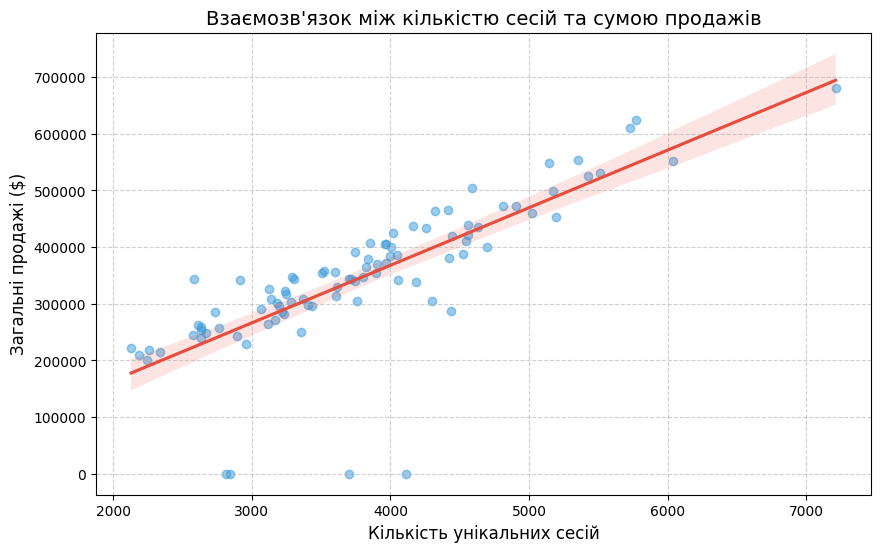

In [ ]:
plt.figure(figsize=(10, 6))


sns.regplot(data=daily_metrics, x="total_sessions", y="total_sales",scatter_kws={"color": "#3498DB", "alpha": 0.5}, line_kws={"color": "#E74C3C"})

plt.title("Взаємозв'язок між кількістю сесій та сумою продажів", fontsize=14)
plt.xlabel("Кількість унікальних сесій", fontsize=12)
plt.ylabel("Загальні продажі ($)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [ ]:
from scipy.stats import pearsonr

data = daily_metrics["total_sessions"], daily_metrics["total_sales"]
df = pd.DataFrame(data)

# Calculate p-value
print(f"Test statistic and p-value: {pearsonr(daily_metrics["total_sessions"], daily_metrics["total_sales"])}")

# Calculate Pearson correlation
pearson_corr = daily_metrics["total_sessions"].corr(daily_metrics["total_sales"])
print(f"Pearson Correlation: {pearson_corr}")


Test statistic and p-value: PearsonRResult(statistic=np.float64(0.7910809164540891), pvalue=np.float64(6.483532312080735e-21))
Pearson Correlation: 0.7910809164540887


Коефіцієнт кореляції Пірсона r = 0.79 свідчить про сильний позитивний лінійний зв'язок. Коли кількість сесій зростає, сума продажів майже завжди зростає пропорційно. Результат є статистично значущим. Ймовірність того, що такий зв'язок між сесіями та продажами є випадковим збігом, практично дорівнює нулю.

continent   Americas      Asia   Europe
date                                   
2020-11-01  132002.5   63823.0  46908.0
2020-11-02  193861.0   79370.0  75710.8
2020-11-03  294529.8  126737.8  67692.0
2020-11-04  200009.5   66602.0  65915.0
2020-11-05  182988.2  117608.4  86540.0
...              ...       ...      ...
2021-01-27  166735.5   66783.1  48156.1
2021-01-28       0.0       0.0      0.0
2021-01-29       0.0       0.0      0.0
2021-01-30       0.0       0.0      0.0
2021-01-31       0.0       0.0      0.0

[92 rows x 3 columns]


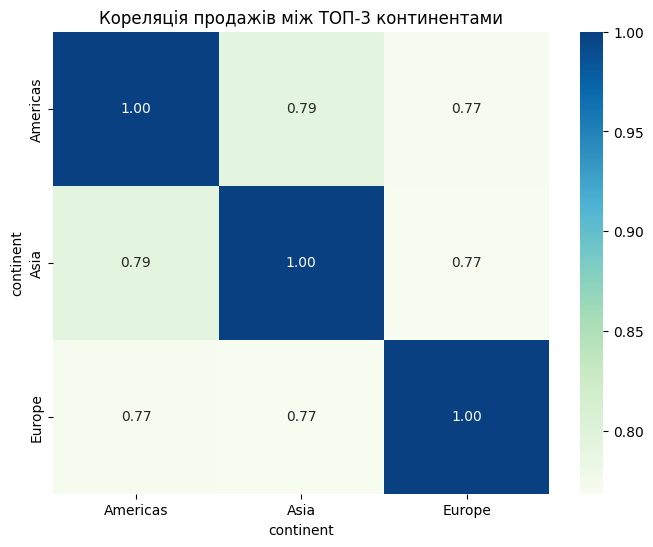

In [ ]:
# Знаходимо ТОП-3 континенти за доходом
top_3_continents = df.groupby("continent")["price"].sum().nlargest(3).index

#групуємо континенти за датой та сумуємо
cont_daily_sales = df[df["continent"].isin(top_3_continents)].groupby(["date", "continent"])["price"].sum().reset_index().fillna(0)
pivot_cont = cont_daily_sales.pivot(index="date", columns="continent", values="price")
print(pivot_cont)


# Рахуємо кореляцію між стовпцями (континентами)
corr_matrix = pivot_cont.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="GnBu", fmt=".2f")
plt.title("Кореляція продажів між ТОП-3 континентами")
plt.show()


Кореляція між усіма трьома континентами дуже висока (0.77 – 0.79). Це означає, що піки та падіння продажів відбуваються одночасно в усьому світі, тому можемо зробити висновок, що доцільно проводити спільні маркетингові кампанії для всіх регіонів одночасно — вони спрацюють.

In [ ]:
from scipy.stats import shapiro

print("Тест Шапіро-Вілка на нормальність розподілу:")
for continent in pivot_cont.columns:
    stat, p = shapiro(pivot_cont[continent])
    print(f"{continent}: p-value = {p:.4f}")
    if p > 0.05:
        print(f"  — Дані {continent} розподілені нормально.")
    else:
        print(f"  — Дані {continent} НЕ мають нормального розподілу (відхиляємо H0).")

Тест Шапіро-Вілка на нормальність розподілу:
Americas: p-value = 0.0195
  — Дані Americas НЕ мають нормального розподілу (відхиляємо H0).
Asia: p-value = 0.0036
  — Дані Asia НЕ мають нормального розподілу (відхиляємо H0).
Europe: p-value = 0.0359
  — Дані Europe НЕ мають нормального розподілу (відхиляємо H0).


Так як розподілення ненормальне, використовуємо метод Спірмана для знаходження статистичної значущості, який краще покаже дані з піковими даними (з викидами).

In [ ]:
from scipy.stats import spearmanr

method = "spearman"

print(f"\nАналіз взаємозв'язків (Метод: {method.capitalize()}):")

continents = list(pivot_cont.columns)
for i in range(len(continents)):
    for j in range(i + 1, len(continents)):
        c1, c2 = continents[i], continents[j]

        # Розрахунок кореляції
        corr, p_val = spearmanr(pivot_cont[c1], pivot_cont[c2])

        print(f"\nПара: {c1} <—> {c2}")
        print(f"  Коефіцієнт кореляції: {corr:.4f}")
        print(f"  p-value: {p_val:.4e}")

        if p_val < 0.05:
            print("  Результат: Зв'язок СТАТИСТИЧНО ЗНАЧУЩИЙ (p < 0.05).")
        else:
            print("  Результат: Зв'язок НЕ є значущим (може бути випадковим).")


Аналіз взаємозв'язків (Метод: Spearman):

Пара: Americas <—> Asia
  Коефіцієнт кореляції: 0.7099
  p-value: 2.3234e-15
  Результат: Зв'язок СТАТИСТИЧНО ЗНАЧУЩИЙ (p < 0.05).

Пара: Americas <—> Europe
  Коефіцієнт кореляції: 0.6726
  p-value: 2.1036e-13
  Результат: Зв'язок СТАТИСТИЧНО ЗНАЧУЩИЙ (p < 0.05).

Пара: Asia <—> Europe
  Коефіцієнт кореляції: 0.6571
  p-value: 1.1291e-12
  Результат: Зв'язок СТАТИСТИЧНО ЗНАЧУЩИЙ (p < 0.05).


Зв'язок між цими метриками є реальним і закономірним.

traffic_source    Direct   Organic  Referral
date                                        
2020-11-01       54669.5   86081.0   44450.0
2020-11-02       81561.5  133845.8   43236.0
2020-11-03      102909.5  164064.9  103464.4
2020-11-04       79683.6  109893.1   51445.4
2020-11-05       83367.6  118528.4   73580.2


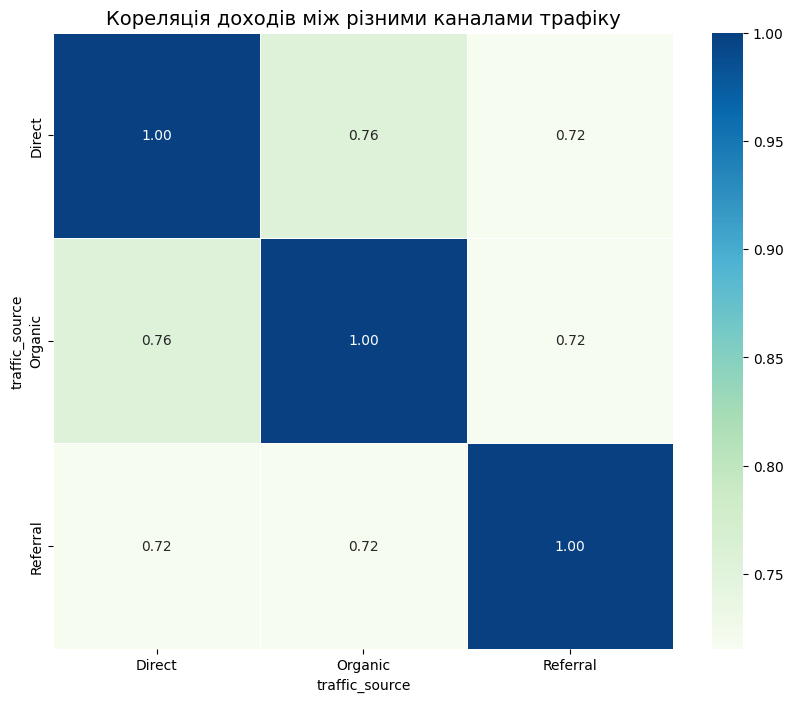


Статистична значущість:
Direct vs Organic: p-value = 3.2491e-18 (Значущо: True)
Direct vs Referral: p-value = 1.1051e-15 (Значущо: True)
Organic vs Referral: p-value = 9.0110e-16 (Значущо: True)


In [ ]:
# 1. Очищення
exclude_channels = ["Data deleted", "Unknown", "<other>", "Undefined"]
df_clean = df[~df["traffic_source"].str.capitalize().isin(exclude_channels)].copy()


# 2. групування
traffic_daily_sales = df_clean.groupby(["date", "traffic_source"])["price"].sum().reset_index().fillna(0)

# pivot
pivot_table = traffic_daily_sales.pivot(index="date", columns="traffic_source", values="price").fillna(0)

print(pivot_table.head())

# 3. Розрахунок матриці кореляції
traffic_corr = pivot_table.corr(method="spearman")

# 4. Візуалізація
plt.figure(figsize=(10, 8))
sns.heatmap(traffic_corr, annot=True, cmap="GnBu", fmt=".2f", linewidths=0.5)
plt.title("Кореляція доходів між різними каналами трафіку", fontsize=14)
plt.show()

# 5. Статистична значущість (p-value)
from scipy.stats import spearmanr
print("\nСтатистична значущість:")
cols = pivot_table.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        rho, p = spearmanr(pivot_table[cols[i]], pivot_table[cols[j]])
        print(f"{cols[i]} vs {cols[j]}: p-value = {p:.4e} (Значущо: {p < 0.05})")

Спостерігається найсильніший зв'язок між Direct та Organic (0.76).Значущість p-value < 10^(-15) підтверджує, що цей зв'язок закономірний.

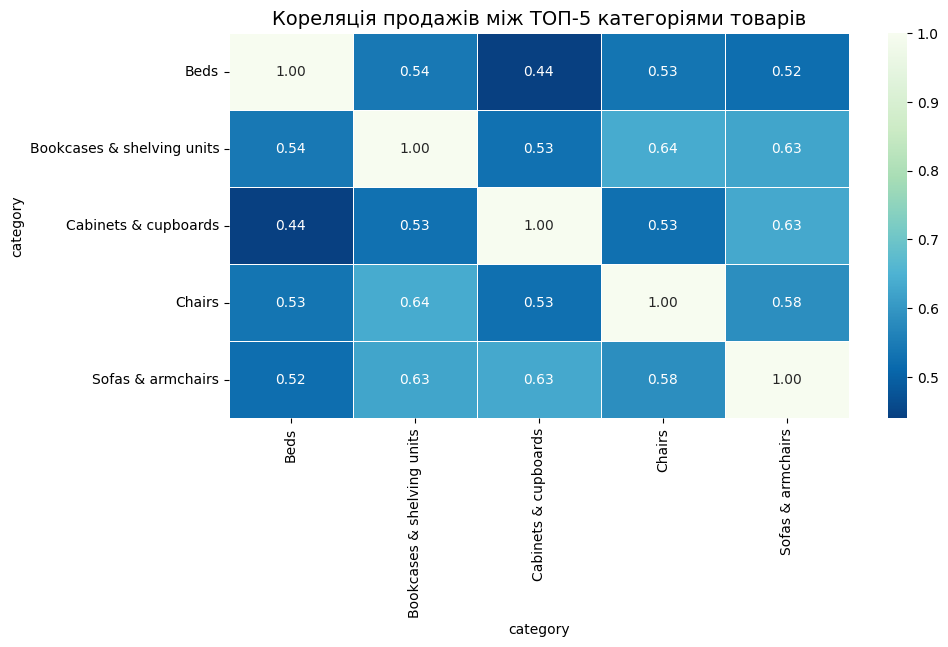

Beds vs Bookcases & shelving units:
  Коефіцієнт (r) = 0.54, p-value = 4.6908e-08 (ЗНАЧУЩИЙ)
Beds vs Cabinets & cupboards:
  Коефіцієнт (r) = 0.44, p-value = 1.7588e-05 (ЗНАЧУЩИЙ)
Beds vs Chairs:
  Коефіцієнт (r) = 0.53, p-value = 7.9134e-08 (ЗНАЧУЩИЙ)
Beds vs Sofas & armchairs:
  Коефіцієнт (r) = 0.52, p-value = 1.8644e-07 (ЗНАЧУЩИЙ)
Bookcases & shelving units vs Cabinets & cupboards:
  Коефіцієнт (r) = 0.53, p-value = 1.1906e-07 (ЗНАЧУЩИЙ)
Bookcases & shelving units vs Chairs:
  Коефіцієнт (r) = 0.64, p-value = 2.5854e-11 (ЗНАЧУЩИЙ)
Bookcases & shelving units vs Sofas & armchairs:
  Коефіцієнт (r) = 0.63, p-value = 7.1890e-11 (ЗНАЧУЩИЙ)
Cabinets & cupboards vs Chairs:
  Коефіцієнт (r) = 0.53, p-value = 1.3449e-07 (ЗНАЧУЩИЙ)
Cabinets & cupboards vs Sofas & armchairs:
  Коефіцієнт (r) = 0.63, p-value = 4.3229e-11 (ЗНАЧУЩИЙ)
Chairs vs Sofas & armchairs:
  Коефіцієнт (r) = 0.58, p-value = 2.4628e-09 (ЗНАЧУЩИЙ)


In [ ]:
top_5_categories = df.groupby("category")["price"].sum().nlargest(5).index

cat_daily_sales = df[df["category"].isin(top_5_categories)].groupby(["date", "category"])["price"].sum().reset_index()


pivot_cat = cat_daily_sales.pivot(index="date", columns="category", values="price").fillna(0)

cat_corr = pivot_cat.corr(method="spearman")


plt.figure(figsize=(10, 5))
sns.heatmap(cat_corr, annot=True, cmap="GnBu_r", fmt=".2f", linewidths=0.5)
plt.title("Кореляція продажів між ТОП-5 категоріями товарів", fontsize=14)
plt.show()

#Статистична значущість взаємозв'язків між категоріями:
cols = pivot_cat.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        rho, p = spearmanr(pivot_cat[c1], pivot_cat[c2])

        significance = "ЗНАЧУЩИЙ" if p < 0.05 else "НЕ значущий"
        print(f"{c1} vs {c2}:")
        print(f"  Коефіцієнт (r) = {rho:.2f}, p-value = {p:.4e} ({significance})")


Найвищу кореляцію мають Bookcases з Chairs та Sofas (0.63 – 0.64). Категорія Beds має найнижчу кореляцію з іншими (0.44 з шафами).
Люди часто купують меблі для вітальні (стільці, софи, полиці) одним махом або в межах одного періоду оновлення інтер'єру. Ліжка купують більш відокремлено.

device       Desktop    Mobile   Tablet
date                                   
2020-11-01  144445.0   99698.5    149.0
2020-11-02  206727.3  137269.5  11510.0
2020-11-03  304473.8  180602.8  13903.0
2020-11-04  212227.7  118324.4   8635.0
2020-11-05  249682.0  138256.0   3338.6


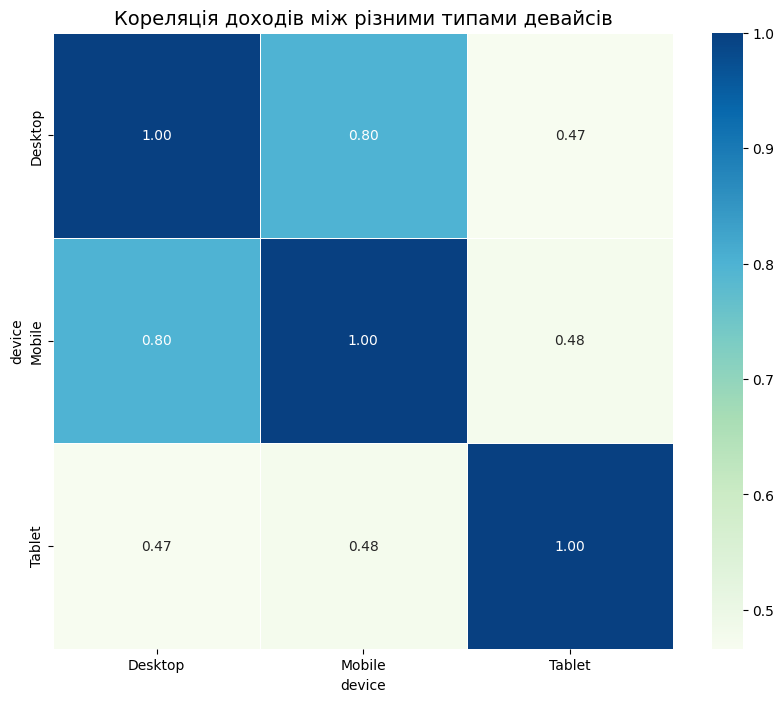


Статистична значущість:
Desktop vs Mobile: p-value = 1.4084e-21 (Значущо: True)
Desktop vs Tablet: p-value = 2.7941e-06 (Значущо: True)
Mobile vs Tablet: p-value = 1.6099e-06 (Значущо: True)


In [ ]:
# групування
device_daily_sales = df.groupby(["date", "device"])["price"].sum().reset_index().fillna(0)

# pivot
pivot_table = device_daily_sales.pivot(index="date", columns="device", values="price").fillna(0)

print(pivot_table.head())

# Розрахунок матриці кореляції
traffic_corr = pivot_table.corr(method="spearman")

# 4. Візуалізація
plt.figure(figsize=(10, 8))
sns.heatmap(traffic_corr, annot=True, cmap="GnBu", fmt=".2f", linewidths=0.5)
plt.title("Кореляція доходів між різними типами девайсів", fontsize=14)
plt.show()

# 5. Статистична значущість (p-value)
from scipy.stats import spearmanr
print("\nСтатистична значущість:")
cols = pivot_table.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        rho, p = spearmanr(pivot_table[cols[i]], pivot_table[cols[j]])
        print(f"{cols[i]} vs {cols[j]}: p-value = {p:.4e} (Значущо: {p < 0.05})")

Кореляція Desktop і Mobile дуже висока (0.80). Проте Tablet має значно слабший зв'язок з іншими пристроями (0.47 – 0.48).

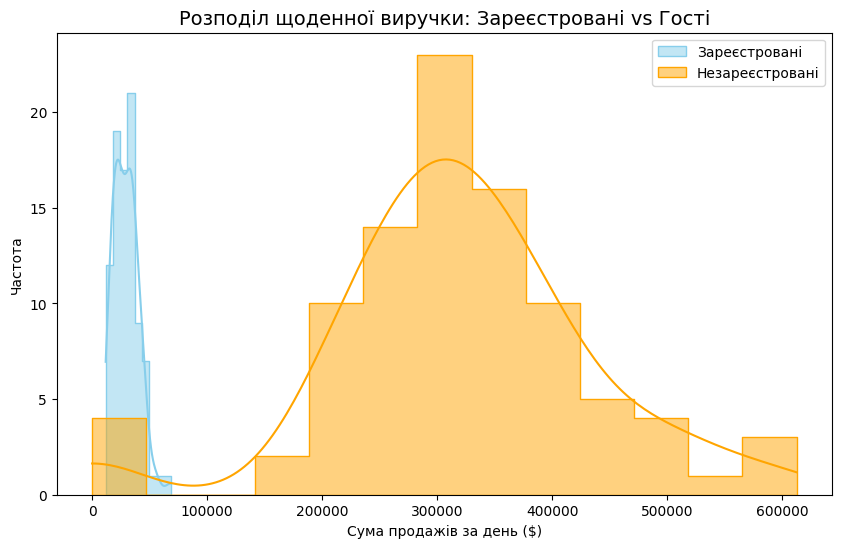

In [ ]:
from scipy import stats

# 1. Розподіляємо на дві групи
registered_daily = df[df["account_id"].notna()].groupby("date")["price"].sum()
guest_daily = df[df["account_id"].isna()].groupby("date")["price"].sum()


plt.figure(figsize=(10, 6))
sns.histplot(registered_daily, kde=True, color="skyblue", label="Зареєстровані", element="step")
sns.histplot(guest_daily, kde=True, color="orange", label="Незареєстровані", element="step")
plt.title("Розподіл щоденної виручки: Зареєстровані vs Гості", fontsize=14)
plt.xlabel("Сума продажів за день ($)")
plt.ylabel("Частота")
plt.legend()
plt.show()

####Перевірка на нормальність:

In [ ]:
shapiro_reg = stats.shapiro(registered_daily)
shapiro_guest = stats.shapiro(guest_daily)

print(f"Тест Шапіро (Зареєстровані): p-value = {shapiro_reg.pvalue:.4f}")
print(f"Тест Шапіро (Гості): p-value = {shapiro_guest.pvalue:.4f}")

Тест Шапіро (Зареєстровані): p-value = 0.0073
Тест Шапіро (Гості): p-value = 0.0012


Дані не є нормальними (p < 0.05). У такому разі ми використовуємо U-тест Манна-Уїтні для порівняння.

In [ ]:
# Виконуємо тест Манна-Уїтні (непараметричний аналог T-тесту)
stat, p_value = stats.mannwhitneyu(registered_daily, guest_daily, alternative='two-sided')

print(f"\n--- Результати тесту Манна-Уїтні ---")
print(f"Статистика: {stat:.2f}")
print(f"p-value: {p_value:.4e}")

# Інтерпретація
if p_value < 0.05:
    print("Висновок: Різниця між групами СТАТИСТИЧНО ЗНАЧУЩА. Поведінка користувачів відрізняється.")
else:
    print("Висновок: Статистично значущої різниці НЕ виявлено. Групи купують однаково.")


--- Результати тесту Манна-Уїтні ---
Статистика: 352.00
p-value: 3.8805e-26
Висновок: Різниця між групами СТАТИСТИЧНО ЗНАЧУЩА. Поведінка користувачів відрізняється.


Цей тест ідеальний для грошових даних. На відміну від T-тесту, він не "лякається" аномальних сплесків (викидів), які ми бачили на попередніх графіках у грудні.

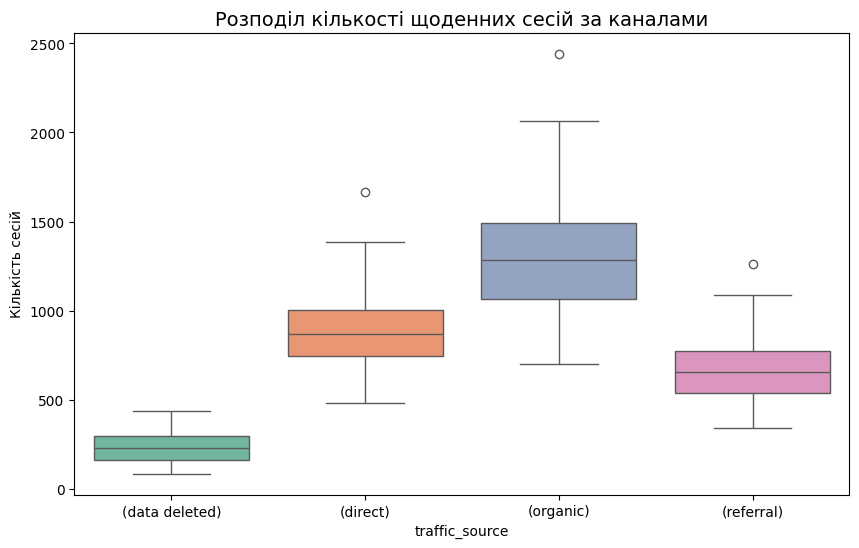

In [ ]:
# 1. Очищення
exclude_channels = ["Data deleted", "Unknown", "<other>", "Undefined"]
df_clean = df[~df["traffic_source"].str.capitalize().isin(exclude_channels)].copy()

#групуємо по даті за кожним каналом
session_by_channel = df_clean.groupby(["date", "traffic_source"])["session_id"].nunique().reset_index()

plt.figure(figsize=(10, 6))
sns.boxplot(data=session_by_channel, x="traffic_source", y="session_id", hue="traffic_source", palette="Set2", legend=False)
plt.title("Розподіл кількості щоденних сесій за каналами", fontsize=14)
plt.ylabel("Кількість сесій")
plt.show()

In [ ]:
from scipy import stats

# 1. Групуємо кількість сесій за датою та типом девайса
device_sessions = df.groupby(["date", "device"])["session_id"].nunique().reset_index()

# 2. Перевірка на нормальність для кожної групи
for device in device_sessions["device"].unique():
    data = device_sessions[device_sessions["device"] == device]["session_id"]

    # Тест Шапіро-Вілка (працює найкраще для вибірок до 5000 значень)
    stat, p_value = stats.shapiro(data)

    print(f"\nДевайс: {device}")
    print(f"Статистика: {stat:.4f}, p-value: {p_value:.4e}")

    if p_value > 0.05:
        print("Висновок: Розподіл НОРМАЛЬНИЙ (p > 0.05)")
    else:
        print("Висновок: Розподіл НЕ нормальний (p <= 0.05)")


Девайс: desktop
Статистика: 0.9631, p-value: 1.0511e-02
Висновок: Розподіл НЕ нормальний (p <= 0.05)

Девайс: mobile
Статистика: 0.9761, p-value: 8.8316e-02
Висновок: Розподіл НОРМАЛЬНИЙ (p > 0.05)

Девайс: tablet
Статистика: 0.9732, p-value: 5.5169e-02
Висновок: Розподіл НОРМАЛЬНИЙ (p > 0.05)


Так як розподіл у Desktop  не нормальний тому краще використати тест Кендалла:

Матриця кореляції Кендалла:
device    desktop    mobile    tablet
device                               
desktop  1.000000  0.909178  0.727850
mobile   0.909178  1.000000  0.719202
tablet   0.727850  0.719202  1.000000

--- Перевірка значущості (p-value) ---
desktop vs mobile: tau=0.909, p-value=1.1075e-37 (ЗНАЧУЩА)
desktop vs tablet: tau=0.728, p-value=1.5668e-24 (ЗНАЧУЩА)
mobile vs tablet: tau=0.719, p-value=5.4468e-24 (ЗНАЧУЩА)


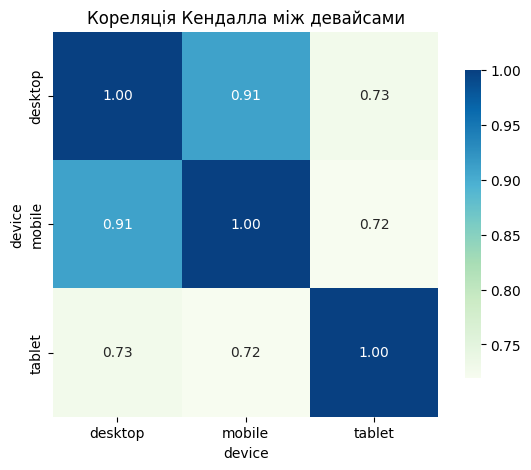

In [ ]:
# 1. группування за датою та кількістю сессій
device_sessions = df.groupby(["date", "device"])["session_id"].nunique().reset_index()

# 2. Створюємо pivot-таблицю
pivot_device = device_sessions.pivot(index="date", columns="device", values="session_id").fillna(0)

print("Матриця кореляції Кендалла:")
# 3. Розрахунок кореляції методом Кендалла
kendall_corr = pivot_device.corr(method="kendall")
print(kendall_corr)

# 4. Аналіз статистичної значущості (p-value) для кожної пари
print("\n--- Перевірка значущості (p-value) ---")
cols = pivot_device.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        d1, d2 = cols[i], cols[j]
        tau, p = stats.kendalltau(pivot_device[d1], pivot_device[d2])

        status = "ЗНАЧУЩА" if p < 0.05 else "НЕ значуща"
        print(f"{d1} vs {d2}: tau={tau:.3f}, p-value={p:.4e} ({status})")

plt.figure(figsize=(7, 5))
sns.heatmap(kendall_corr, annot=True, cmap="GnBu", fmt=".2f", square=True, cbar_kws={"shrink": .8})
plt.title("Кореляція Кендалла між девайсами", fontsize=12)
plt.show()

Кореляція між Desktop та Mobile надзвичайно висока (0.91). Це означає, що клієнти переходять між пристроями: можуть шукати товар на телефоні, а завершувати покупку на комп'ютері. Планшети (Tablet) тримаються осторонь (0.72), що є нормою для ринку.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# 1. Фільтруємо дані для двох континентів
europe_data = df[df["continent"] == "Europe"]
americas_data = df[df["continent"] == "Americas"]

# 2. Рахуємо загальну кількість сесій
total_europe = europe_data["session_id"].nunique()
total_americas = americas_data["session_id"].nunique()

# 3. Рахуємо кількість органічних сесій
organic_europe = europe_data[europe_data["traffic_source"] == "Organic"]["session_id"].nunique()
organic_americas = americas_data[americas_data["traffic_source"] == "Organic"]["session_id"].nunique()

print(f"Європа: {organic_europe} органічних із {total_europe} загалом ({(organic_europe/total_europe)*100:.2f}%)")
print(f"Америка: {organic_americas} органічних із {total_americas} загалом ({(organic_americas/total_americas)*100:.2f}%)")

Європа: 22190 органічних із 65135 загалом (34.07%)
Америка: 65783 органічних із 193179 загалом (34.05%)


Оскільки ми порівнюємо дві незалежні частки (пропорції), найкращим вибором є Z-тест для двох часток.

Нульова гіпотеза ($H_0$): Долі органічного трафіку в Європі та Америці однакові.

Альтернативна гіпотеза ($H_1$): Долі суттєво відрізняються.

In [ ]:

count = [organic_europe, organic_americas]
nobs = [total_europe, total_americas]

z_stat, p_value = proportions_ztest(count, nobs)

print(f"\n--- Результати Z-тесту ---")
print(f"Z-статистика: {z_stat:.4f}")
print(f"p-value: {p_value:.4e}")

if p_value < 0.05:
    print("Висновок: Відмінність СТАТИСТИЧНО ЗНАЧУЩА. Регіони мають різну структуру трафіку.")
else:
    print("Висновок: Статистично значущої відмінності НЕ виявлено. Долі органіки однакові.")


--- Результати Z-тесту ---
Z-статистика: 0.0691
p-value: 9.4493e-01
Висновок: Статистично значущої відмінності НЕ виявлено. Долі органіки однакові.


Структура залучення користувачів у цих двох регіонах ідентична.Те, що спрацювало для ранжування в США, так само добре працює в ЄС.

In [ ]:
from scipy.stats import mannwhitneyu

# 1. Створюємо вибірки чеків Americas
usa_checks = df[df["continent"] == "Americas"]["price"].dropna()

# Вибираємо ціни для Європи
europe_checks = df[df["continent"] == "Europe"]["price"].dropna()

print(f"Кількість замовлень у Америці: {len(usa_checks)}")
print(f"Кількість замовлень у Європі: {len(europe_checks)}")

# 2. Розрахуємо медіани, щоб розуміти напрямок різниці
print(f"\nМедіанний чек США: ${usa_checks.median():.2f}")
print(f"Медіанний чек Європи: ${europe_checks.median():.2f}")

Кількість замовлень у Америці: 18553
Кількість замовлень у Європі: 6261

Медіанний чек США: $445.00
Медіанний чек Європи: $450.00


In [ ]:
# 3. Виконуємо тест
stat, p_value = mannwhitneyu(usa_checks, europe_checks, alternative='two-sided')

print(f"\n--- Результати тесту Манна-Уїтні ---")
print(f"U-статистика: {stat}")
print(f"p-value: {p_value:.4e}")

if p_value < 0.05:
    print("Висновок: Різниця СТАТИСТИЧНО ЗНАЧУЩА. Клієнти на цих ринках витрачають по-різному.")
else:
    print("Висновок: Статистично значущої різниці НЕ виявлено. Витрати клієнтів ідентичні.")


--- Результати тесту Манна-Уїтні ---
U-статистика: 57352570.0
p-value: 1.3765e-01
Висновок: Статистично значущої різниці НЕ виявлено. Витрати клієнтів ідентичні.


Хоча в Європі медіана трохи вища, тест Манна-Уїтні показує, що загальний розподіл витрат в обох регіонах майже однаковий.

Ми порівняли платоспроможність клієнтів у США та Європі. Попри різну кількість замовлень, середній рівень витрат на одну покупку в цих регіонах ідентичний.

Це означає, що ми можемо використовувати однакові цінові стратегії та маркетингові пропозиції для обох континентів. Нам не потрібно створювати окремі "дешеві" або "преміальні" лінійки товарів спеціально під один із цих ринків - клієнти купують однаково.

##Загальні висновки:

Ми побачили, що бізнес має чітко вираженого лідера. Північна Америка генерує основний обсяг доходу. Велика концентрація в одному регіоні - це стабільність, але низька присутність на інших континентах свідчить про потенціал для експансії. Треба проаналізувати причини низької конверсії в регіонах з великим трафіком, але низьким доходом.

В розрізі девайсів, ми помітили, що хоча мобільний трафік може бути великим, Desktop часто лідирує за сумою чека. Користувачі вибирають на ходу з телефона, а фіналізують дорогу покупку з комп'ютера.

Канали з найвищим доходом не завжди мають найбільшу кількість сесій. Якість трафіку важливіша за кількість.

Ми виявили, що 83% доходу приносять підписані користувачі (Is Unsubscribed = False). Це підтверджує, що розсилки працюють на відмінно.

Верифіковані користувачі - це основа прибутку. Навіть якщо їх чисельно менше, їхній внесок у бюджет критичний.

In [ ]:
# Зберігаємо файл в формат CSV в Tableau
from google.colab import files

file_name = "project 1.csv"
df.to_csv(file_name, index=False)
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[Візуалізація в Tableau](https://public.tableau.com/views/Project1_17747078333880/Project1?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)